**ML Pipeline on Tesla EV Deliveries and Production Data**

The following workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, hyperparameter tuning and time series forecasting. The objective is to analyze the factors affecting Tesla deliveries and predict future delivery trends using ML techniques.


Dataset Source: https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025

In [58]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

In the above section, the required python libraries are imported. Pandas and numpy are used for data manipulation, matplotlib and seaborn are used for visualization and scikit-learn is used for ml model building and evaluation.

In [59]:
#Loading dataset
df=pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In the above section, the dataset is loaded into a pandas dataframe.

In [60]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


>DATA UNDERSTANDING

In [61]:
#Data Understanding
df.describe()

df.isnull().sum() #For missing values
df.duplicated().sum() #For duplicate or repititive values
df.drop_duplicates(inplace=True)

The above section examines shape of dataset, data types of columns, summary statistics and the presence of missing or duplicate values.

>DATA CLEANING AND PREPROCESSING

In [62]:
#Data preprocessing
#Handling missing values
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
  df[col]=df[col].fillna(df[col].median())

cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
  df[col]=df[col].fillna(df[col].mode()[0])

df['Year']=pd.to_datetime(df['Year'])

Missing values and duplicate values can negatively affect the model performance. Hence, they are replaced using the median, while catrgorical data is filled using mode. Duplicate records are removed to improve data quality.

>EXPLORATORY DATA ANALYSIS

This helps in identifying patterns, trends and relationships within the given dataset through various visualizations.

i] Deliveries over time: Shows how deliveries have changed over the years and helps identify growth trends and fluctuations in demand.

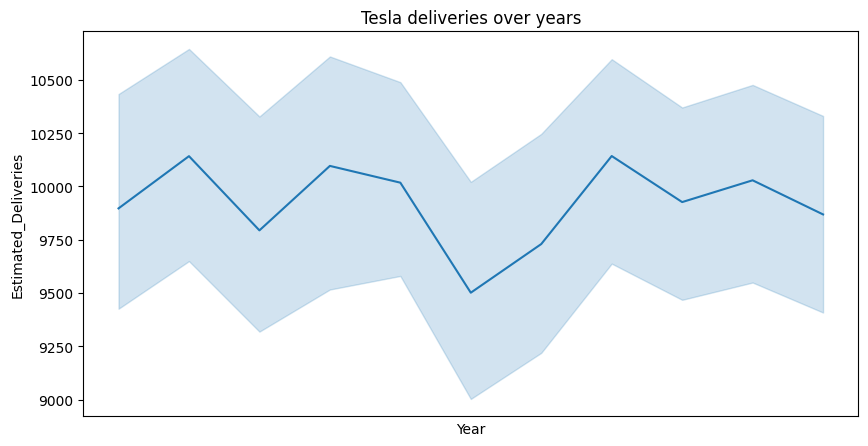

In [63]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Year',y='Estimated_Deliveries',data=df)
plt.title("Tesla deliveries over years")
plt.show()

ii] Production trend: Illustrates the productions units manufactured over time and it helps in understanding operational efficiency.

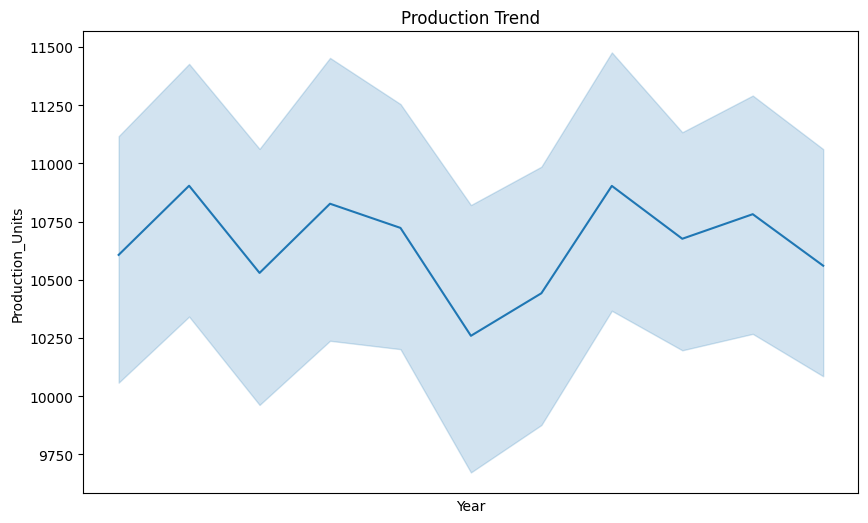

In [64]:
plt.figure(figsize=(10,6))
sns.lineplot(x='Year',y='Production_Units',data=df)
plt.title("Production Trend")
plt.show()

iii] Deliveries by region: Compares deliveries across different regions, it also helps identify markets with highest demand for the products.

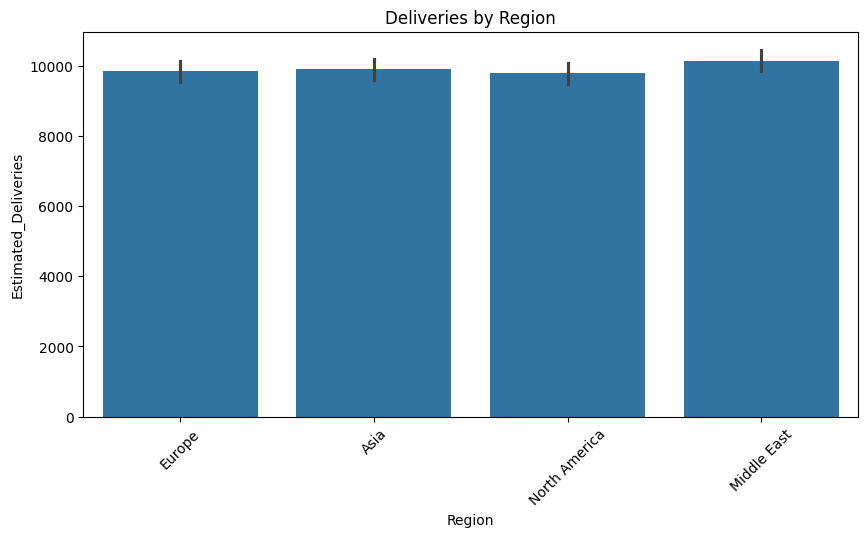

In [65]:
plt.figure(figsize=(10,5))
sns.barplot(x='Region',y='Estimated_Deliveries',data=df)
plt.xticks(rotation=45)
plt.title("Deliveries by Region")
plt.show()

iv] Deliveries by vehcile model: It helps in understanding which models contribute to the most overall deliveries.

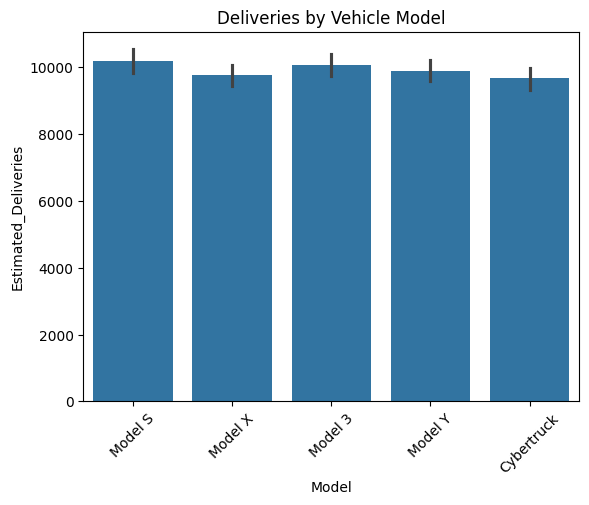

In [66]:
sns.barplot(x='Model',y='Estimated_Deliveries',data=df)
plt.xticks(rotation=45)
plt.title("Deliveries by Vehicle Model")
plt.show()

v] Price Distribution: Shows how vehicle prices are spread across the dataset. It helps identify the common price ranges and possible outliers.

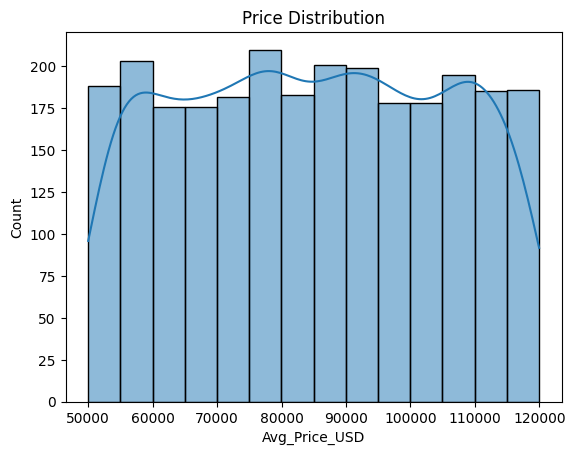

In [67]:
sns.histplot(df['Avg_Price_USD'],kde=True)
plt.title("Price Distribution")
plt.show()

vi] Correlation Heatmap: Measures the relationship between numerical variables. Strong positive or negative correlations help identify important features for ML models.

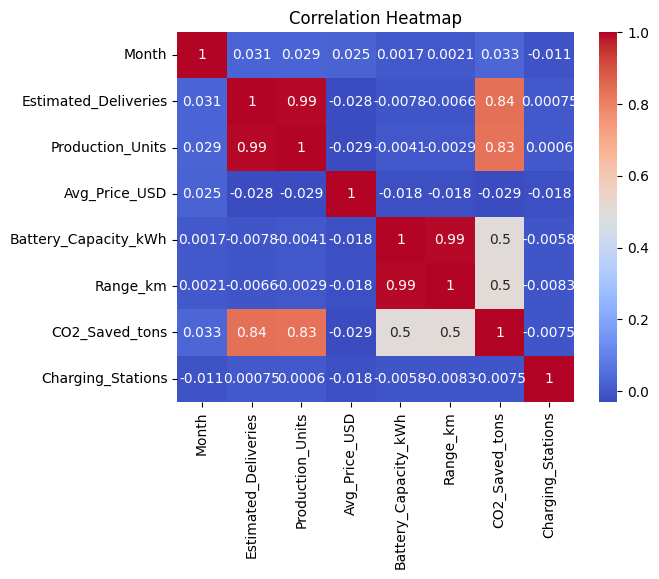

In [68]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

vii] Delivery distribution across regions: Helps understand demand regio-wise that helps in analysing the region specific market trends and future predictions and improvements.

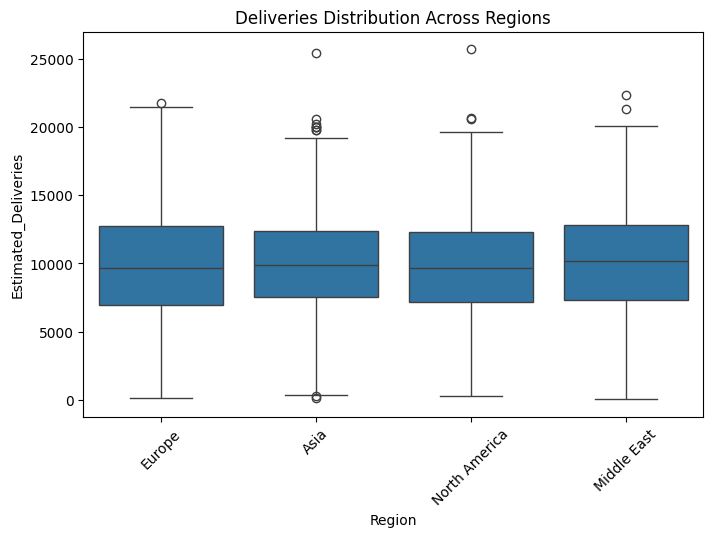

In [69]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Region',y='Estimated_Deliveries',data=df)
plt.title("Deliveries Distribution Across Regions")
plt.xticks(rotation=45)
plt.show()

>FEATURE ENGINEERING

It involves creating new features from existing data to improve model performance.

1. Delivery Efficiency: calculated as ratio of deliveries to production units. This indicates how effectively production is converted into actual deliveries.
2. Price per kilometer: Measures the cost of vehicle range and provides additional insight into vehicle value.
3. Quarter feature: Derived from month column and it captures seasonal patterns that may affect sales and deliveries.

>Encoding

ML models require numerical inputs. Therefore, categorical variables such as region and model are converted into numerical form using label encoding.

In [70]:
#Feature Engineering

df['Delivery_Efficiency']=(df['Estimated_Deliveries']/df['Production_Units'])
df['Price_per_km']=(df['Avg_Price_USD']/df['Range_km'])
df['Quarter']=((df['Month']-1)//3)+1

le_region=LabelEncoder()
df['Region']=le_region.fit_transform(df['Region'])
le_model=LabelEncoder()
df['Model']=le_model.fit_transform(df['Model'])
le_source=LabelEncoder()
df['Source_Type']=le_source.fit_transform(df['Source_Type'])


>REGRESSION MODELING

We create two regression models, and then predict tesla estimated deliveries using production,pricing, battery and region.

1. Linear Regression : Simple ML algorithm that models the relationship between input features and the target variable using linear equation.

2. Random Forest Regression : It combines multiple decision trees and is more complex than simple linear regression.

In [71]:
#Regression Modeling
y=df['Estimated_Deliveries']

X=df[['Month','Region','Model','Production_Units','Avg_Price_USD','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations','Quarter']]

print(X.dtypes)
X_train_reg, X_test_reg, y_train_reg, y_test_reg=train_test_split(X,y, test_size=0.2, random_state=42)

lr=LinearRegression()
lr.fit(X_train_reg, y_train_reg)
pred_lr=lr.predict(X_test_reg)
print("Linear Regression: ")
print("MAE: ",mean_absolute_error(y_test_reg, pred_lr))
print("RMSE: ",np.sqrt(mean_squared_error(y_test_reg, pred_lr)))
print("R2: ",r2_score(y_test_reg,pred_lr))

rf=RandomForestRegressor(random_state=42)
rf.fit(X_train_reg,y_train_reg)
pred_rf=rf.predict(X_test_reg)
print("Random Forest: ")
print("MAE: ",mean_absolute_error(y_test_reg, pred_rf))
print("RMSE: ",np.sqrt(mean_squared_error(y_test_reg,pred_rf)))
print("R2: ",r2_score(y_test_reg,pred_rf))


Month                     int64
Region                    int64
Model                     int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Charging_Stations         int64
Quarter                   int64
dtype: object
Linear Regression: 
MAE:  309.9605248798974
RMSE:  383.304941530711
R2:  0.990143577201592
Random Forest: 
MAE:  309.504375
RMSE:  395.9735109026272
R2:  0.9894812833396955


>HYPERPARAMETER TUNING

Tuning is done using GridSearchCV to identify the best parameter combination for the random forest model. It helps in model performance and prediction accuracy.

In [72]:
#Hyperparameter Tuning
params={'n_estimators':[50,100,200],'max_depth':[3,5,10]}

grid=GridSearchCV(RandomForestRegressor(random_state=42),params,cv=3,scoring='r2')
grid.fit(X_train_reg,y_train_reg)
print(grid.best_params_)

best_rf=grid.best_estimator_
pred_best=best_rf.predict(X_test_reg)
print("Tuned Random Forest: ")
print("MAE: ",mean_absolute_error(y_test_reg,pred_best))
print("RMSE: ",np.sqrt(mean_squared_error(y_test_reg, pred_best)))
print("R2: ",r2_score(y_test_reg,pred_best))


{'max_depth': 10, 'n_estimators': 100}
Tuned Random Forest: 
MAE:  318.7650717998251
RMSE:  404.88426136754373
R2:  0.9890025428442402


>FEATURE IMPORTANCE

It identifies which variables contribute most to the prediction of tesla deliveries. This helps in extracting valuable business insights.

                Feature  Importance
3      Production_Units    0.990934
7        CO2_Saved_tons    0.002611
6              Range_km    0.001625
4         Avg_Price_USD    0.001492
8     Charging_Stations    0.001314
0                 Month    0.000681
2                 Model    0.000524
1                Region    0.000436
9               Quarter    0.000203
5  Battery_Capacity_kWh    0.000180


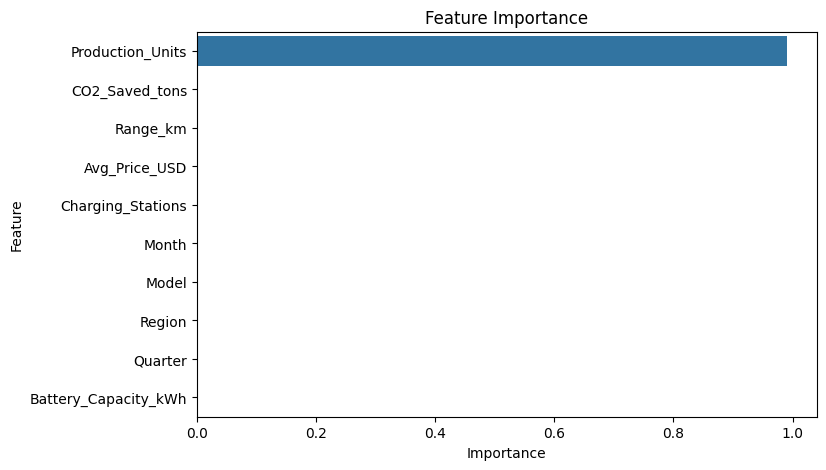

In [73]:
importance=pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_})
importance=importance.sort_values(by='Importance',ascending=False)
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance',y='Feature',data=importance)
plt.title("Feature Importance")
plt.show()


>FORECAST VISUALIZATION

The graph compares actual deliveries with predicted deliveries. It gives us a visual understanding of how well the forecasting model captires delivery trends over time.

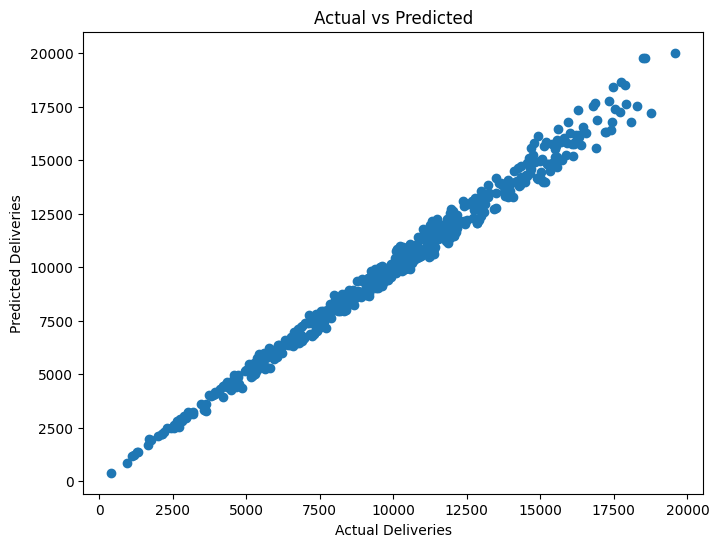

In [74]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_reg,pred_best)
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title('Actual vs Predicted')
plt.show()

>RESIDUAL ANALYSIS

It evaluates the errors made by the model. Ideally, residuals should be randomly distributed around zero, indicating a well-performing model.

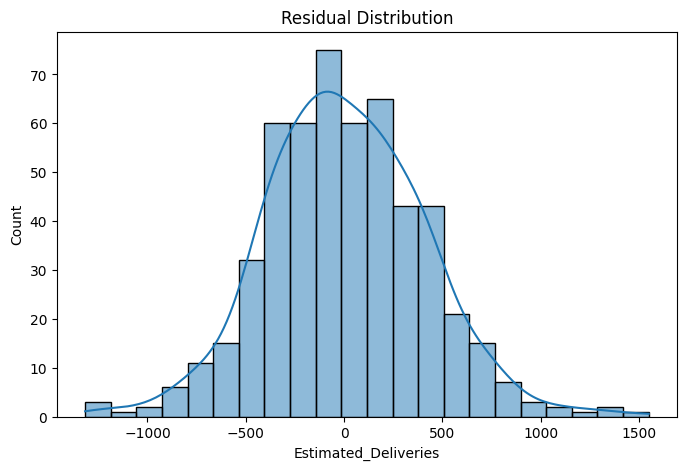

In [75]:
residuals=y_test_reg-pred_best
plt.figure(figsize=(8,5))
sns.histplot(residuals,kde=True)
plt.title("Residual Distribution")
plt.show()

>TIME SERIES FORECASTING

Used to predict future deliveries based on data. A lag feature is created using previous delivery values to model future trends.

/tmp/ipykernel_82412/2124572542.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']=pd.to_datetime(df['Year'].astype(str)+'-'+df['Month'].astype(str)+'-01')


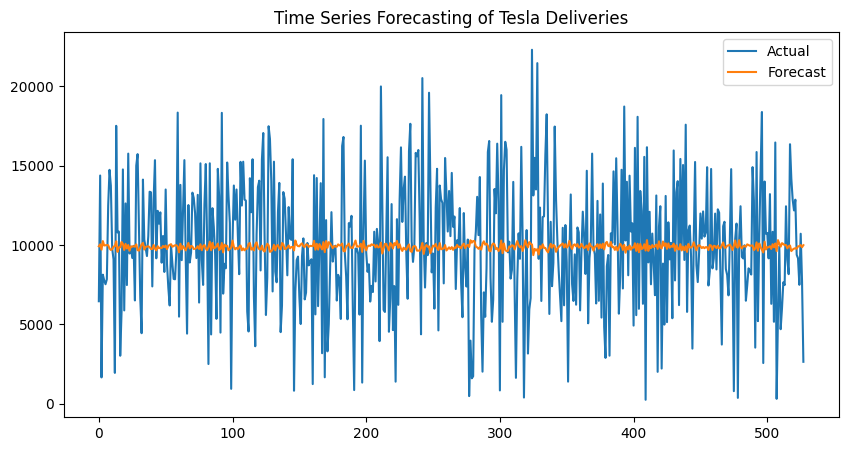

In [76]:
#Time series forecasting
df['Date']=pd.to_datetime(df['Year'].astype(str)+'-'+df['Month'].astype(str)+'-01')
df=df.sort_values('Date')

df['Prev_Deliveries']=(df['Estimated_Deliveries'].shift(1))
df.dropna(inplace=True)

X_ts=df[['Prev_Deliveries']]
y_ts=df['Estimated_Deliveries']

split=int(len(df)*0.8)
X_train_ts=X_ts[:split]
X_test_ts=X_ts[split:]
y_train_ts=y_ts[:split]
y_test_ts=y_ts[split:]

forecast_model=LinearRegression()
forecast_model.fit(X_train_ts,y_train_ts)
forecast=forecast_model.predict(X_test_ts)

plt.figure(figsize=(10,5))
plt.plot(y_test_ts.values, label='Actual')
plt.plot(forecast,label='Forecast')
plt.legend()
plt.title("Time Series Forecasting of Tesla Deliveries")
plt.show()

In [77]:
results=pd.DataFrame({'Model':['Linear regression','Random Forest','Tuned Random Forest'],'R2 Score':[r2_score(y_test_reg,pred_lr),r2_score(y_test_reg,pred_rf),r2_score(y_test_reg,pred_best)],
                      'MAE':[mean_absolute_error(y_test_reg,pred_lr),mean_absolute_error(y_test_reg,pred_rf),mean_absolute_error(y_test_reg,pred_best)],'RMSE':[np.sqrt(mean_squared_error(y_test_reg,pred_lr)),np.sqrt(mean_squared_error(y_test_reg,pred_rf)),np.sqrt(mean_squared_error(y_test_reg,pred_best))]})
print(results)

                 Model  R2 Score         MAE        RMSE
0    Linear regression  0.990144  309.960525  383.304942
1        Random Forest  0.989481  309.504375  395.973511
2  Tuned Random Forest  0.989003  318.765072  404.884261


>RESULTS

The machine learning models were successfully trained and evaluated using Tesla EV delivery and production data. Linear Regression provided a baseline model, while random forest regression acheived improved performance by capturing more complex relationships among features. Hyperparameter tuning furthur enhanced the random forest model. Time series forecasting was also implemented to estimate future delivery trends using delivery information.

>Business Insights

1. Production units showed strong relationship with estimated deliveries, which suggests that production capacity significantly affects sales.
2. Delivery volumes varied across different regions, suggesting that market demand differs geographically.
3. Certain models of vehicles contributed more heavily to overall deliveries than others.
4. Battery capacity and vehicle range were important factors affecting delivery trends, emphasizing customer preference for higher-performance electric vehicles.
5. Feature importance analysis indicated that production-related variables were among the most influential predictors of deliveries.


>CONCLUSION

The above workflow included data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning and time series forecasting.
Multiple ML models were evaluated using MAE, RMSE and R2 score.
Random forest regression achieved better predictive performance compared to linear regression, while time series forecasting demonstrated the ability to estimate future delivery trends based on data given.